<a href="https://colab.research.google.com/github/abhishekgautam6113/Student_Mental_Health_Productivity/blob/MLAlgorithms/DevOps_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Predict whether a student is likely to experience burnout based on lifestyle and mental health indicators***



---

A dataset has been Created to perform the same testing which consists of various attributes contributing to decidng whether a student will face burnout or not.
Various Machine Learning Algorithms have been applied to test the same.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

In [ ]:
df = pd.read_excel("/content/student_mental_health_productivity_dataset - Copy.xlsx", sheet_name=0)

In [ ]:
print("🔍 Dataset Overview:")
print(df.head().to_string())
print("\n🧾 Summary:")
print(df.describe(include='all').to_string())
print("\n💡 Missing Values:\n", df.isnull().sum().to_string())

🔍 Dataset Overview:
   Age  Gender  Average Sleep (hrs)  Daily Screen Time (hrs)  Exercise Frequency (per week)  Study Hours (per day) Diet Quality Social Interaction Level  Stress Level (1-10)  Productivity Level (1-10) Burnout
0   24  Female                  2.7                      8.7                              4                    2.5      Average                   Medium                    7                          6     Yes
1   21  Female                  6.5                      7.1                              3                    1.8         Good                     High                    6                          5      No
2   28    Male                  9.8                      5.2                              3                    3.5      Average                   Medium                    2                          7      No
3   25  Female                  7.5                      8.3                              3                    3.9      Average                 

<ipython-input-13-34c6ed067255>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Burnout", palette="coolwarm")


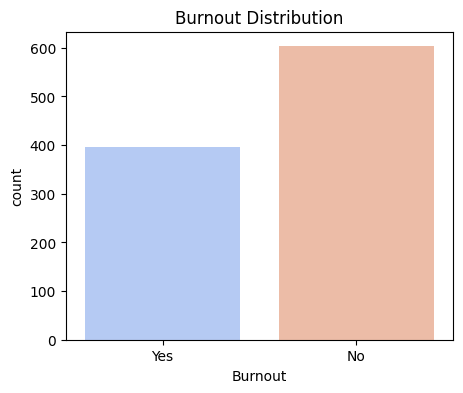

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Burnout", palette="coolwarm")
plt.title("Burnout Distribution")
plt.show()

In [ ]:
categorical_cols = ['Gender', 'Diet Quality', 'Social Interaction Level']
numerical_cols = [col for col in df.columns if col not in categorical_cols + ['Burnout']]

label_encoder = LabelEncoder()
df['Burnout'] = label_encoder.fit_transform(df['Burnout'])  # Yes=1, No=0

X = df.drop('Burnout', axis=1)
y = df['Burnout']

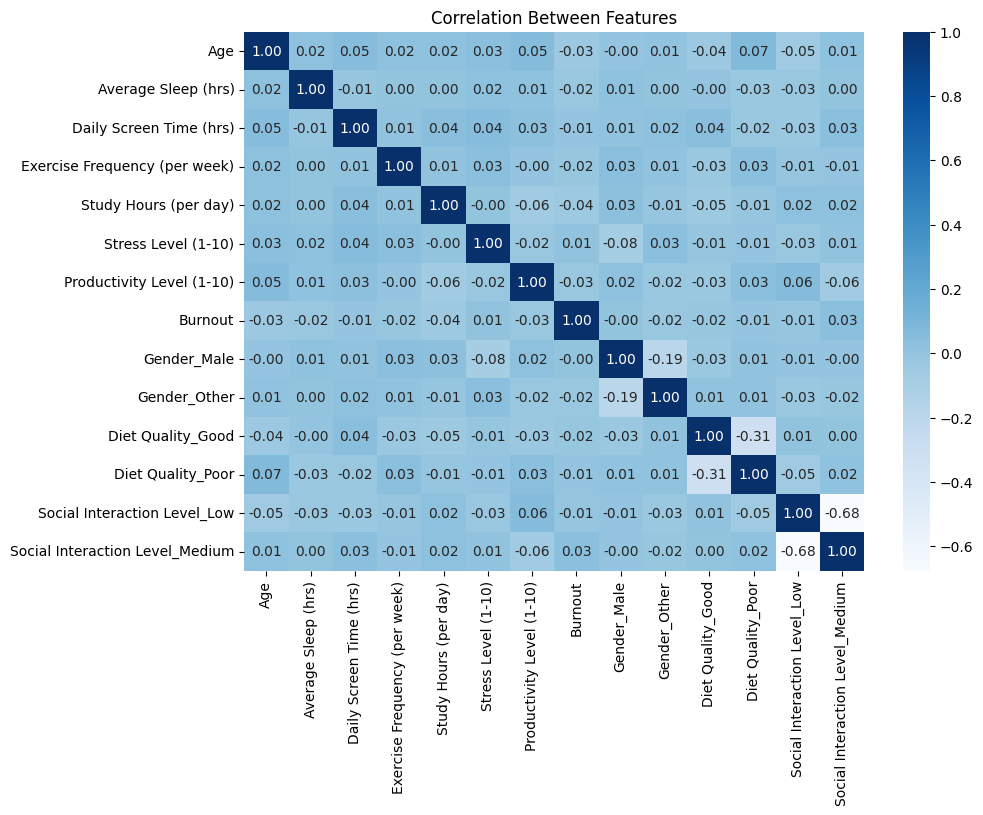

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)  # for correlation only
plt.figure(figsize=(10, 7))
sns.heatmap(df_encoded.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Between Features")
plt.show()

In [ ]:

X_train, X_test, y_train, y_test = X, X, y, y

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=150, learning_rate=0.1)
}

results = {}


 Random Forest - Accuracy: 0.9290
              precision    recall  f1-score   support

  No Burnout       0.89      1.00      0.94       603
     Burnout       1.00      0.82      0.90       397

    accuracy                           0.93      1000
   macro avg       0.95      0.91      0.92      1000
weighted avg       0.94      0.93      0.93      1000

📊 According to Random Forest, average predicted student burnout chance is: 39.59%


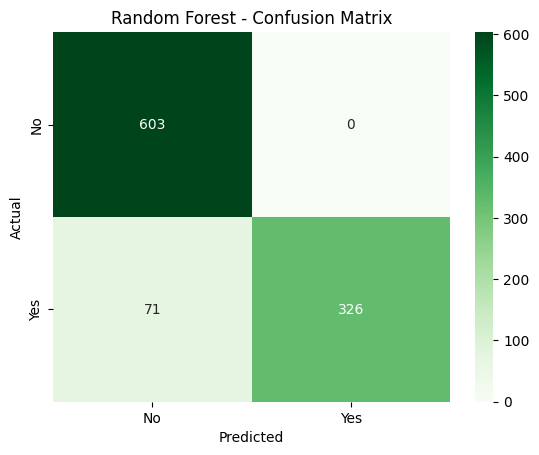


 Logistic Regression - Accuracy: 0.6000
              precision    recall  f1-score   support

  No Burnout       0.60      0.99      0.75       603
     Burnout       0.29      0.01      0.01       397

    accuracy                           0.60      1000
   macro avg       0.44      0.50      0.38      1000
weighted avg       0.48      0.60      0.46      1000

📊 According to Logistic Regression, average predicted student burnout chance is: 39.71%


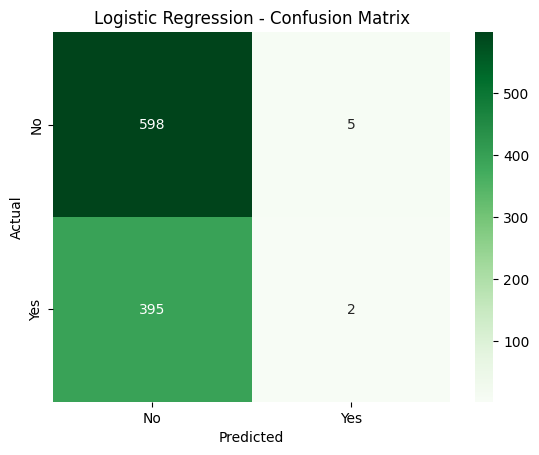


 Gradient Boosting - Accuracy: 0.8320
              precision    recall  f1-score   support

  No Burnout       0.79      0.98      0.88       603
     Burnout       0.95      0.61      0.74       397

    accuracy                           0.83      1000
   macro avg       0.87      0.79      0.81      1000
weighted avg       0.86      0.83      0.82      1000

📊 According to Gradient Boosting, average predicted student burnout chance is: 39.71%


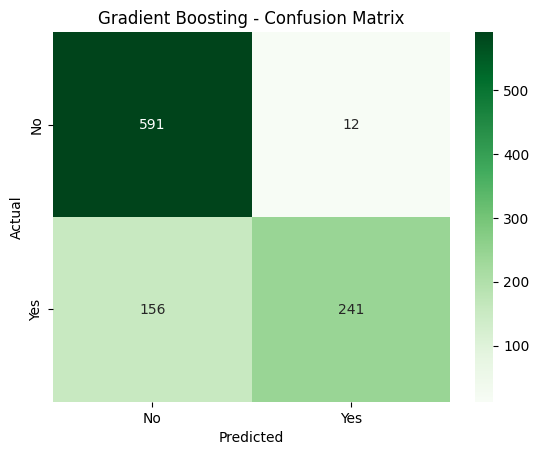

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:08:22] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



 XGBoost - Accuracy: 0.9780
              precision    recall  f1-score   support

  No Burnout       0.97      1.00      0.98       603
     Burnout       0.99      0.95      0.97       397

    accuracy                           0.98      1000
   macro avg       0.98      0.97      0.98      1000
weighted avg       0.98      0.98      0.98      1000

📊 According to XGBoost, average predicted student burnout chance is: 39.73%


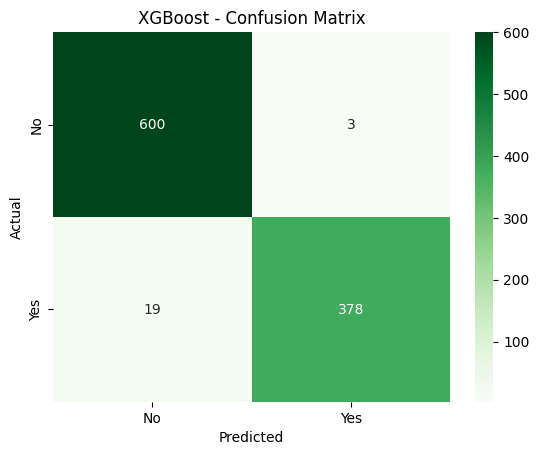

In [ ]:

for name, model in models.items():
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n {name} - Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["No Burnout", "Burnout"]))

    if hasattr(clf.named_steps['classifier'], "predict_proba"):
        probs = clf.predict_proba(X_test)[:, 1]
        avg_prob = np.mean(probs)
        print(f"📊 According to {name}, average predicted student burnout chance is: {avg_prob * 100:.2f}%")

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Greens", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

<ipython-input-18-7a1d97132fa3>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_df, palette="viridis")


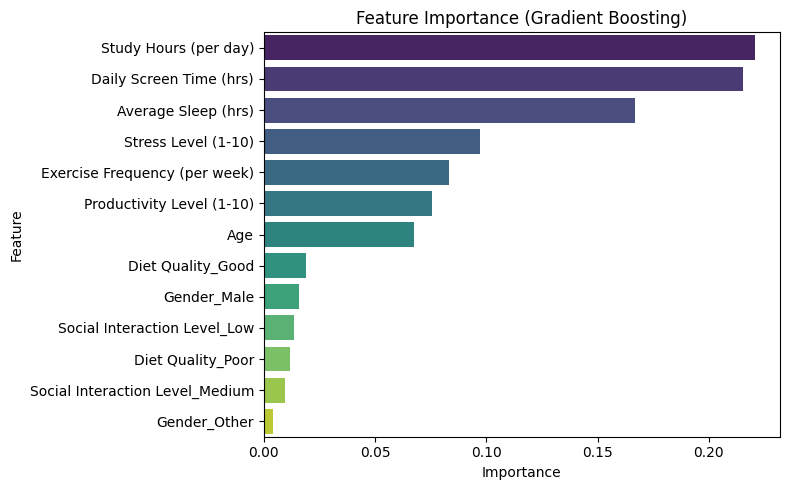

In [ ]:

best_tree_model = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, random_state=42)
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_tree_model)
])
full_pipeline.fit(X_train, y_train)

ohe = preprocessor.named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)
all_features = np.concatenate([ohe_feature_names, numerical_cols])

importances = full_pipeline.named_steps['classifier'].feature_importances_

feat_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x="Importance", y="Feature", data=feat_df, palette="viridis")
plt.title("Feature Importance (Gradient Boosting)")
plt.tight_layout()
plt.show()


In [ ]:
performance_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
performance_df = performance_df.sort_values(by="Accuracy", ascending=False)
print("\nModel Accuracy Comparison:")
print(performance_df)


Model Accuracy Comparison:
                 Model  Accuracy
3              XGBoost     0.978
0        Random Forest     0.929
2    Gradient Boosting     0.832
1  Logistic Regression     0.600
